# Customer Lifetime Value (CLV) Prediction and Segmentation

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay


### Loading Dataset

In [78]:
df=pd.read_csv('Dataset.csv',encoding='latin3')

In [79]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,CREAM CUPID HEARTS COAT HANGER,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,CREAM CUPID HEARTS COAT HANGER,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


### Data Cleaning

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [81]:
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                         Description  Quantity  \
0         536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                 WHITE METAL LANTERN         6   
2         536365    84406B      CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G      CREAM CUPID HEARTS COAT HANGER         6   
4         536365    84029E      CREAM CUPID HEARTS COAT HANGER         6   
...          ...       ...                                 ...       ...   
541904    581587     22613         PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899        CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254       CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255     CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138       BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  CustomerID       

In [82]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [83]:
df.duplicated().sum()

np.int64(5268)

In [84]:
df.shape

(541909, 8)

In [85]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,CREAM CUPID HEARTS COAT HANGER,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,CREAM CUPID HEARTS COAT HANGER,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [86]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [87]:
df=df.dropna(subset=['CustomerID'])

In [88]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [89]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

C:\Users\athra\AppData\Local\Temp\ipykernel_24292\3737639551.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])


In [90]:
df['InvoiceDate']

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 406829, dtype: datetime64[ns]

In [91]:
count=len(df)
df=df[df['Quantity']>0] ##Remove Return Product
df=df[df['UnitPrice']>0] ## Remove Invalid Price
removed_rows=count-len(df)
print(f"Removed Invalid Rows are:{removed_rows}") 

Removed Invalid Rows are:8945


In [92]:
print(f"Remaining Rows are:- {len(df)}")

Remaining Rows are:- 397884


In [93]:
df['Revenue']=df['Quantity']*df['UnitPrice']

In [94]:
df.shape

(397884, 9)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   Revenue      397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


### Distribution of Purchased Quantity

In [96]:
''' 
The Distribution of Purchased quantity was analysisted to understand 
Customer buying bhevaiour 
''';

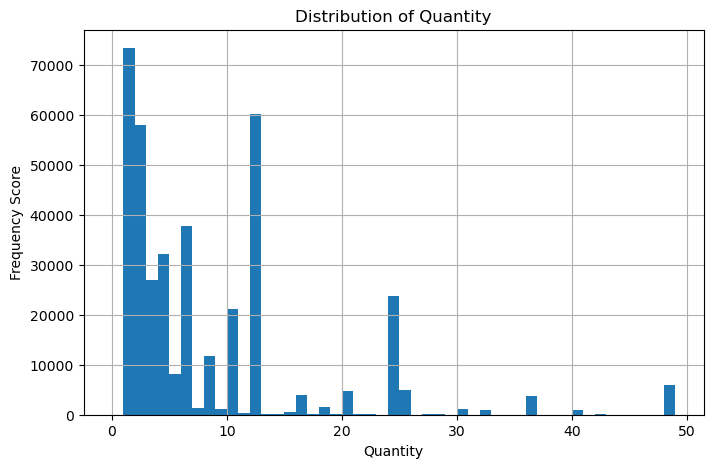

In [97]:

plt.figure(figsize=(8,5))
plt.hist(df['Quantity'],bins=range(0,50))
plt.title("Distribution of Quantity") 
plt.xlabel('Quantity')
plt.ylabel('Frequency Score')
plt.grid()
plt.show()

In [98]:
'''
Observation:- 
Most transactions contains small purchased quantity,
while few transactions involves large purchased quantity
''';

### Distribution of Unit Price

In [99]:
''' 
Distribution of Selling Price of product were analysisted 
''';

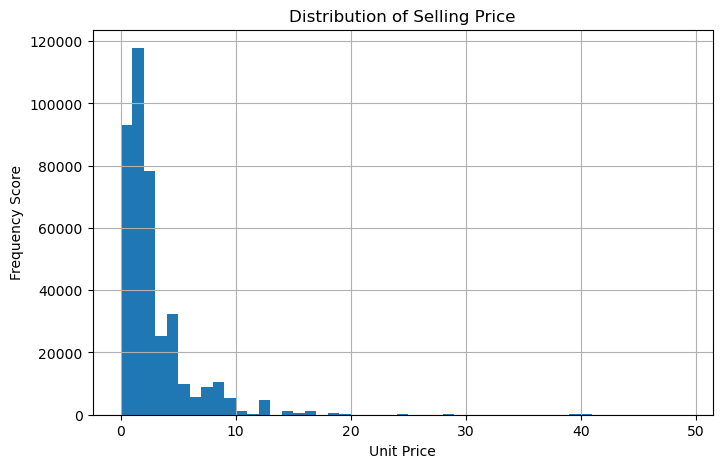

In [100]:
plt.figure(figsize=(8,5))
plt.hist(df['UnitPrice'],bins=range(0,50))
plt.title("Distribution of Selling Price") 
plt.xlabel('Unit Price')
plt.ylabel('Frequency Score')
plt.grid()
plt.show()

In [101]:
revenue_customer=df.groupby('CustomerID')['Revenue'].sum().reset_index()

In [102]:
revenue_customer

,CustomerID,Revenue
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4333,18280.0,180.60
4334,18281.0,80.82
4335,18282.0,178.05
4336,18283.0,2094.88


### Distribution of Revenue Per Customer

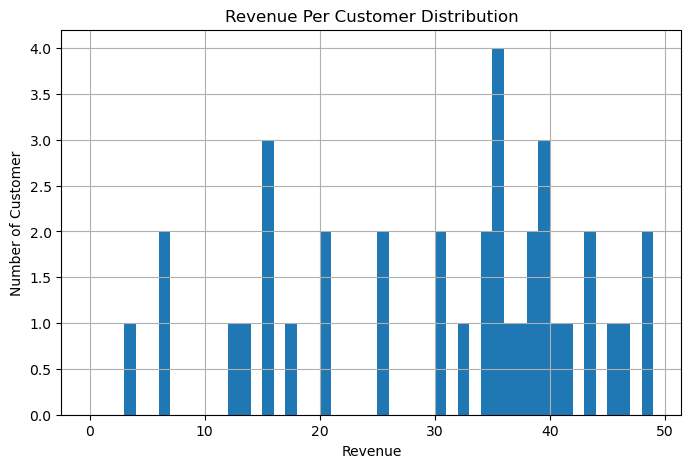

In [103]:
plt.figure(figsize=(8,5))
plt.hist(revenue_customer['Revenue'],bins=range(0,50))
plt.title('Revenue Per Customer Distribution')
plt.xlabel('Revenue')
plt.ylabel('Number of Customer')
plt.grid()
plt.show()

# Purchase Frequency Per Customer 

In [104]:
purchase_frequency=(
    df.groupby('CustomerID')['InvoiceNo'].nunique()
    .reset_index(name='PurchaseFrequency')
)
purchase_frequency.head()

,CustomerID,PurchaseFrequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


# Purchase Frequency Distribution

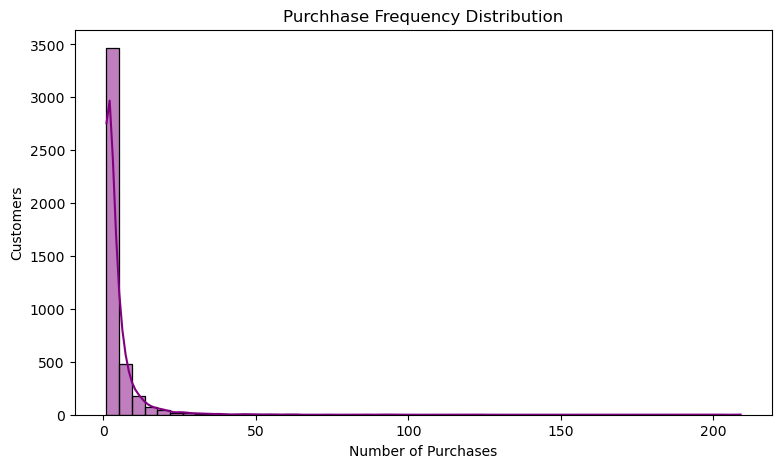

In [105]:
plt.figure(figsize=(9,5))
sns.histplot(
    purchase_frequency['PurchaseFrequency'],
    bins=50,
    kde=True,
    color='purple'
)
plt.title("Purchhase Frequency Distribution")
plt.xlabel('Number of Purchases')
plt.ylabel('Customers')
plt.show()

# Calculate RFM Features

In [106]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'

})

rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# Scatter Plot (Recency vs Monetary)

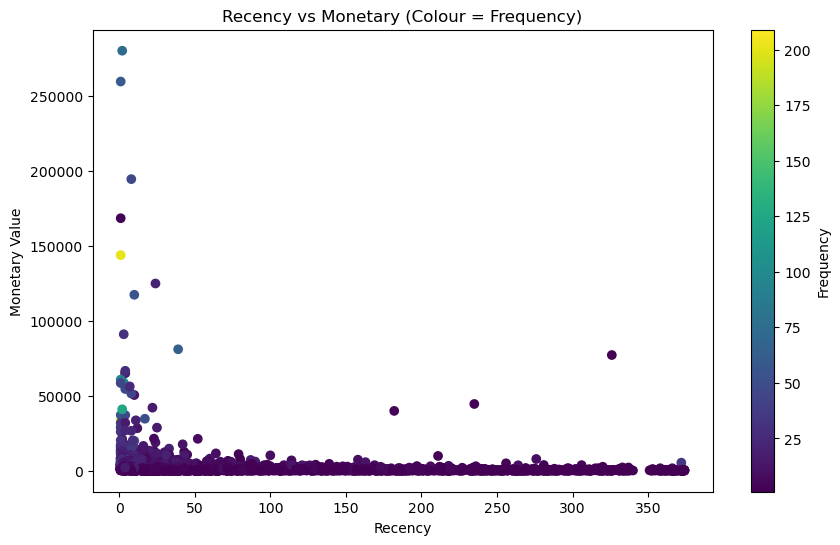

In [107]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=rfm['Frequency'],
    cmap='viridis'
)

plt.xlabel("Recency")
plt.ylabel("Monetary Value")
plt.title("Recency vs Monetary (Colour = Frequency)")

plt.colorbar(scatter, label='Frequency')

plt.show()

# Country-wise Customer Count

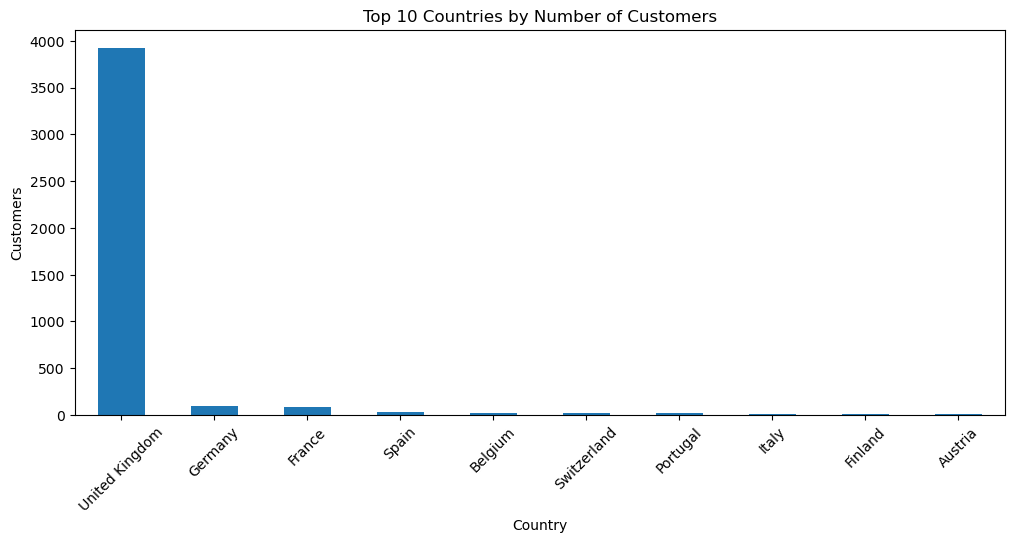

In [108]:
country_customer = (
    df.groupby('Country')['CustomerID']
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))

country_customer.plot(kind='bar')

plt.title("Top 10 Countries by Number of Customers")

plt.xlabel("Country")

plt.ylabel("Customers")

plt.xticks(rotation=45)

plt.show()

# Country-wise Average CLV (Revenue)

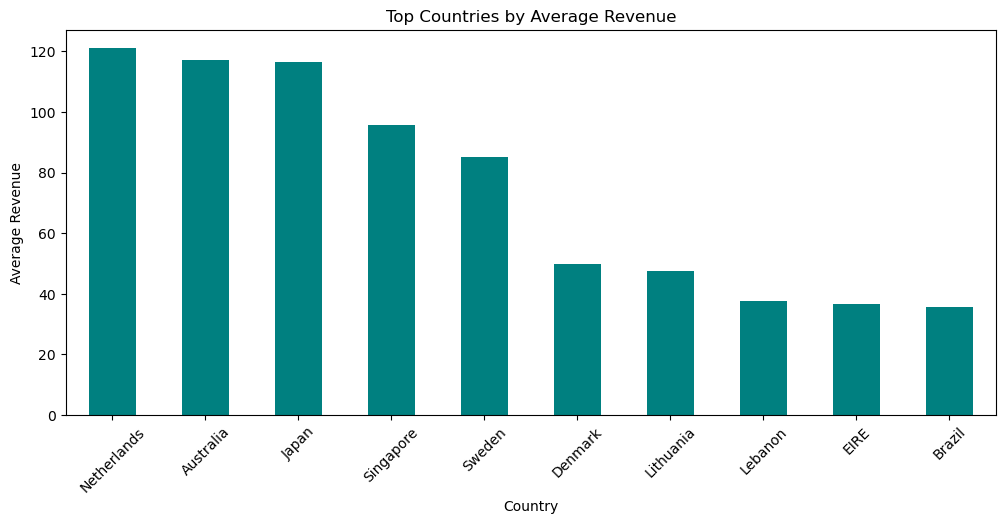

In [109]:
country_revenue = (
    df.groupby('Country')['Revenue']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))

country_revenue.plot(kind='bar', color='teal')

plt.title("Top Countries by Average Revenue")

plt.xlabel("Country")

plt.ylabel("Average Revenue")

plt.xticks(rotation=45)

plt.show()

# Data Preprocessing & CLV Target Creation

#### Define the Cutoff Date

In [110]:
cutoff_date = df['InvoiceDate'].max() - pd.Timedelta(days=90)

print("Cutoff Date:", cutoff_date)

Cutoff Date: 2011-09-10 12:50:00


# Split Dataset into Past and Future Transactions

In [111]:

past_data = df[df['InvoiceDate'] <= cutoff_date]

future_data = df[df['InvoiceDate'] > cutoff_date]

print("Past Transactions :", past_data.shape)
print("Future Transactions :", future_data.shape)


Past Transactions : (236358, 9)
Future Transactions : (161526, 9)


# Create RFM Features from Past Data

In [112]:

reference_date = past_data['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = past_data.groupby('CustomerID').agg({

    'InvoiceDate': lambda x: (reference_date - x.max()).days,

    'InvoiceNo': 'nunique',

    'Revenue': 'sum'

})

rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,235,1,77183.60
12347.0,39,5,2790.86
12348.0,158,3,1487.24
12350.0,219,1,334.40
12352.0,171,5,1561.81


# Create Future CLV Target

In [113]:
future_clv = future_data.groupby('CustomerID')['Revenue'].sum().reset_index()

future_clv.columns = ['CustomerID','CLV']

future_clv.head()

,CustomerID,CLV
0,12347.0,1519.14
1,12348.0,310.00
2,12349.0,1757.55
3,12352.0,944.23
4,12356.0,58.35


# Merge RFM Features with CLV Target

In [114]:
final_df = rfm.merge(
    future_clv,
    on='CustomerID',
    how='left'
)

final_df['CLV'] = final_df['CLV'].fillna(0)

final_df.head()

,CustomerID,Recency,Frequency,Monetary,CLV
0,12346.0,235,1,77183.60,0.00
1,12347.0,39,5,2790.86,1519.14
2,12348.0,158,3,1487.24,310.00
3,12350.0,219,1,334.40,0.00
4,12352.0,171,5,1561.81,944.23


# Check Dataset Shape

In [115]:
print(final_df.shape)

final_df.head()

(3370, 5)


,CustomerID,Recency,Frequency,Monetary,CLV
0,12346.0,235,1,77183.60,0.00
1,12347.0,39,5,2790.86,1519.14
2,12348.0,158,3,1487.24,310.00
3,12350.0,219,1,334.40,0.00
4,12352.0,171,5,1561.81,944.23


# Check Outliers

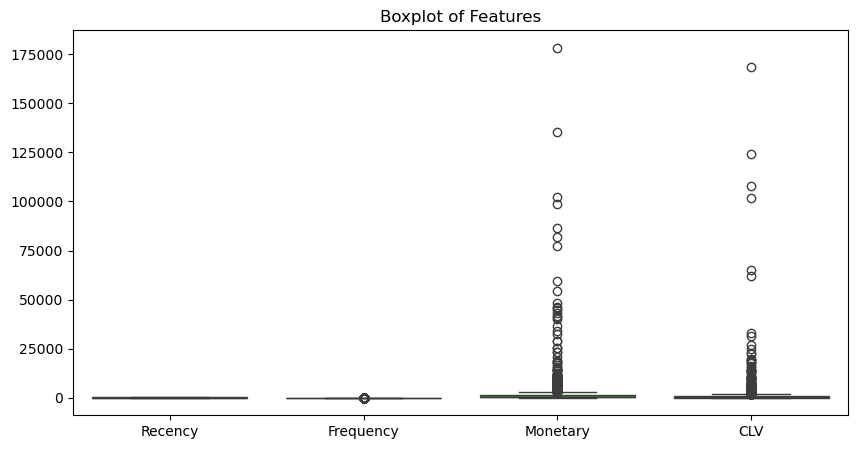

In [116]:
plt.figure(figsize=(10,5))

sns.boxplot(data=final_df[['Recency','Frequency','Monetary','CLV']])

plt.title("Boxplot of Features")

plt.show()

## Removing Outlier

In [128]:
cap_value = final_df['Monetary'].quantile(0.99)

final_df['Monetary'] = np.where(

    final_df['Monetary'] > cap_value,

    cap_value,

    final_df['Monetary']

)

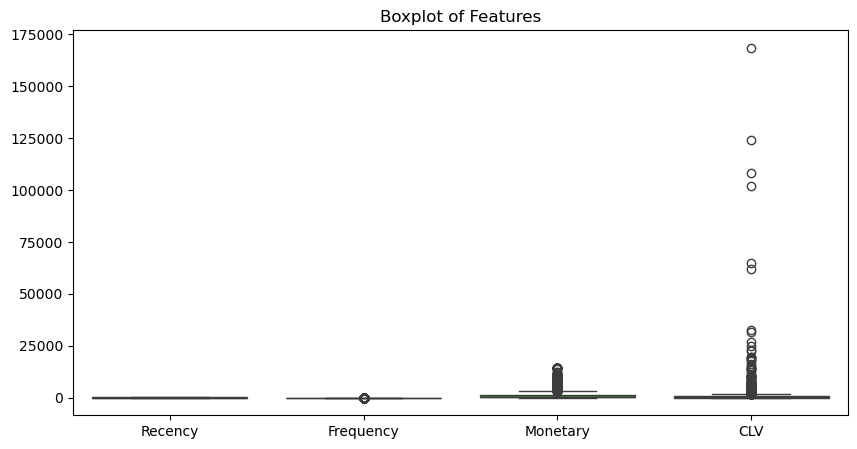

In [129]:
plt.figure(figsize=(10,5))

sns.boxplot(data=final_df[['Recency','Frequency','Monetary','CLV']])

plt.title("Boxplot of Features")

plt.show()

## Feature Scaling

In [130]:
scaler=MinMaxScaler()

In [132]:
scaled_rfm=scaler.fit_transform(final_df)

In [137]:
## Checking Datatype of scaled_rfm
type(scaled_rfm)

numpy.ndarray

In [ ]:
## As fit_tranform returns array object as we converted
## into Datafram
rfm_scaled=pd.DataFrame(scaled_rfm,columns=final_df.columns)

In [136]:
rfm_scaled

,CustomerID,Recency,Frequency,Monetary,CLV
0,0.000000,0.829787,0.000000,1.000000,0.000000
1,0.000168,0.134752,0.030534,0.191807,0.009017
2,0.000337,0.556738,0.015267,0.102120,0.001840
3,0.000673,0.773050,0.000000,0.022807,0.000000
4,0.001010,0.602837,0.030534,0.107250,0.005605
...,...,...,...,...,...
3365,0.998822,0.659574,0.000000,0.012225,0.000000
3366,0.998990,0.315603,0.000000,0.005361,0.000000
3367,0.999158,0.124113,0.000000,0.006695,0.000462
3368,0.999327,0.014184,0.068702,0.076901,0.005783


In [138]:
## Separate X(input) and y(output)
X=rfm_scaled[['Recency','Frequency','Monetary']]
y=rfm_scaled['CLV']

In [141]:
X.shape

(3370, 3)

In [142]:
y.shape

(3370,)

In [143]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=40)

In [144]:
X_test.shape,y_train.shape

((674, 3), (2696,))